

## 1-есеп. Персептрон шешімі
# **Equation:** $z = 2x_1 - x_2 + 1$, Activation: $f(z) = 1$ if $z \ge 0$ else $0$.

(1,0) үшін шығыс: z=2(1)−0+1=3. 3≥0 болғандықтан, шығыс = 1

(0,2) үшін шығыс: z=2(0)−2+1=−1. −1<0 болғандықтан, шығыс = 0

Шешім шекарасының теңдеуі:
 **2x1−x2+1=0**

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron_predict(x1, x2):
    z = 2*x1 - x2 + 1
    return 1 if z >= 0 else 0

# 1. (1, 0) үшін шығыс
out1 = perceptron_predict(1, 0) # 2(1) - 0 + 1 = 3 -> 1
# 2. (0, 2) үшін шығыс
out2 = perceptron_predict(0, 2) # 2(0) - 2 + 1 = -1 -> 0

print(f"(1,0) шығысы: {out1}, (0,2) шығысы: {out2}")
print(f"Шешім шекарасының теңдеуі: 2x1 - x2 + 1 = 0 немесе x2 = 2x1 + 1")


(1,0) шығысы: 1, (0,2) шығысы: 0
Шешім шекарасының теңдеуі: 2x1 - x2 + 1 = 0 немесе x2 = 2x1 + 1


## 2-есеп. XOR мәселесі
# 1. **Неге үйрене алмайды?** Бір қабатты персептрон тек сызықтық жіктелетін (linearly separable) мәліметтерді шеше алады. XOR - сызықтық емес мәселе.

# 2. **Геометриялық түсіндірме:** XOR нүктелерін (0,0),(1,1) және (0,1),(1,0) бір түзу сызықпен бөлу мүмкін емес.
# 3. **Архитектура:** Кем дегенде бір жасырын қабаты (hidden layer) бар Көпқабатты Персептрон (MLP).



#  3-есеп. Активация функцияларын салыстыру
# | Функция | Формула | Диапазон | Туындысы |
# | **Sigmoid** | $1 / (1 + e^{-x})$ | (0, 1) | $\sigma(x)(1 - \sigma(x))$ |
# | **Tanh**    | $(e^x - e^{-x}) / (e^x + e^{-x})$ | (-1, 1) | $1 - \tanh^2(x)$
# | **ReLU**    | $max(0, x)$ | $[0, \infty)$ | $1$ if $x>0$ else $0$ |
#
# **Vanishing gradient:** Sigmoid және Tanh бұл мәселеге бейім, өйткені олардың туындылары өте кіші (0-ге жақын) болып келеді.


>
#  4-есеп. Softmax интерпретациясы
## Given $z = [2, 1, 0]$

In [49]:
z= np.array([2, 1, 0])
exp_z = np.exp(z)
softmax_vals = exp_z / np.sum(exp_z)

print(f"4-есеп Softmax мәндері: {softmax_vals}")
print(f"Ең ықтимал класс: {np.argmax(softmax_vals)} (Класс 0)")
print(f"Қосындысы: {np.sum(softmax_vals)}") # Should be 1.0

4-есеп Softmax мәндері: [0.66524096 0.24472847 0.09003057]
Ең ықтимал класс: 0 (Класс 0)
Қосындысы: 1.0


## 5-есеп Forward propagation
## Given: $x = [1, 2]$, $W = [[1, -1], [2, 0]]$, $b = [0, 1]$, Activation: ReLU

In [50]:
x = np.array([1, 2])
W = np.array([[1, -1], [2, 0]])
b = np.array([0, 1])

z = np.dot(W, x) + b # [1(1)-1(2)+0, 2(1)+0(2)+1] = [-1, 3]
a = np.maximum(0, z) # ReLU([-1, 3]) = [0, 3]

print(f"5-есеп: z = {z}, a = {a}")

5-есеп: z = [-1  3], a = [0 3]


## II. Есептеу есептері (Backpropagation)
## 6-есеп. Жоғалту функциясы (Binary Cross-Entropy)
## $y=1, \hat{y}=0.8$

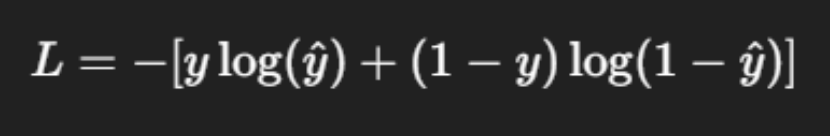

In [51]:
y = 1
y_hat = 0.8
loss = -(y * np.log(y_hat) + (1-y) * np.log(1-y_hat))

print(f"Loss = {loss:.4f}")

Loss = 0.2231


## 7-есеп. Градиент (шығыс қабаты)
# $y=0, \hat{y}=0.3$ $\delta = \hat{y} - y$

In [52]:
delta = 0.3 - 0

print(f"delta = {delta}")

delta = 0.3


### Белгісі оң (+), бұл дегеніміз болжам нақты мәннен жоғары, сондықтан салмақтарды азайту керек

## 8-есеп Жасырын қабаттағы градиент
# $\delta^{(l)} = (W^{(l+1)})^T \delta^{(l+1)} \odot f'(z^{(l)})$

In [53]:
W_next = np.array([[1, 2], [-1, 1]])
delta_next = np.array([0.2, -0.1])
f_prime_z = np.array([1, 0])

delta_l = np.dot(W_next.T, delta_next) * f_prime_z

print(f"delta_l = {delta_l}")

delta_l = [0.3 0. ]


## 9-есеп. Салмақ жаңарту
# $w_{new} = w - \eta \cdot \frac{\partial L}{\partial w}$

In [54]:
w = 0.5
grad = 0.2
eta = 0.1
w_new = w - eta * grad

print(f"Жаңа салмақ = {w_new}")

Жаңа салмақ = 0.48


## III. Практикалық есептер (Implementation)

## 10-есеп. Персептронды нөлден жазу (AND/OR)

In [55]:
class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def train(self, X, y):
        self.weights = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i in range(X.shape[0]):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else 0
                update = self.lr * (y[i] - y_pred)
                self.weights += update * X[i]
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_pred = np.where(linear_output >= 0, 1, 0) #Vectorized prediction
        return y_pred


# Testing AND Logic
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])

p = Perceptron()

p.train(X_and, y_and)


print(f'Салмақтар: {p.weights}')
print(f'Bias: {p.bias}')
print(f'y_pred: {p.predict(X_and)}')


Салмақтар: [0.2 0.1]
Bias: -0.20000000000000004
y_pred: [0 0 0 1]


## 11-есеп. XOR үшін MLP (Simple Implementation)

In [56]:
from sklearn.neural_network import MLPClassifier

X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

# Architecture: 2 inputs, 2 hidden neurons, 1 output

mlp = MLPClassifier(hidden_layer_sizes=(2,), activation='relu', solver='lbfgs', max_iter=1000)
mlp.fit(X_xor, y_xor)

print(f"XOR Prediction: {mlp.predict(X_xor)}")

XOR Prediction: [0 1 1 0]


## 12-есеп. Активация әсері (Effect of Activation Functions)
# Бұл бөлімде ReLU және Tanh функцияларының оқыту жылдамдығы мен градиент тұрақтылығы салыстырылады


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

In [58]:
# XOR Dataset for testing

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 0])

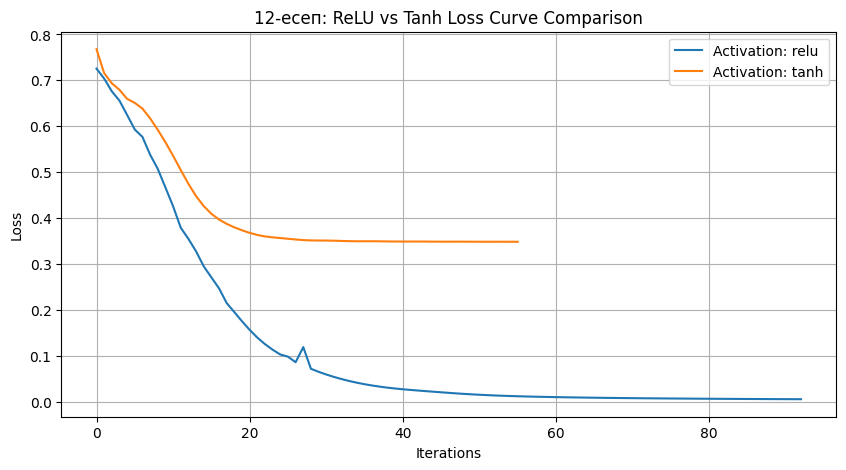

In [59]:
activations = ['relu', 'tanh']
plt.figure(figsize=(10, 5))

for act in activations:
    mlp = MLPClassifier(hidden_layer_sizes=(4, 4), activation=act,
                        learning_rate_init=0.1, max_iter=100, random_state=42)
    mlp.fit(X, y)
    plt.plot(mlp.loss_curve_, label=f'Activation: {act}')

plt.title("12-есеп: ReLU vs Tanh Loss Curve Comparison")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Талдау:
### 1. ReLU оң жақ жарты жазықтықта қанықпайтындықтан, әдетте тезірек жинақталады

### 2. Tanh (-1, 1) аралығында жұмыс істейді және градиенттері кішірек, сондықтан vanishing gradient мәселесіне бейім


## 13-есеп. Learning rate эксперименті
## Бұл бөлімде әртүрлі оқыту жылдамдықтарының ($\eta$) шығын (loss) функциясына әсері зерттеледі


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


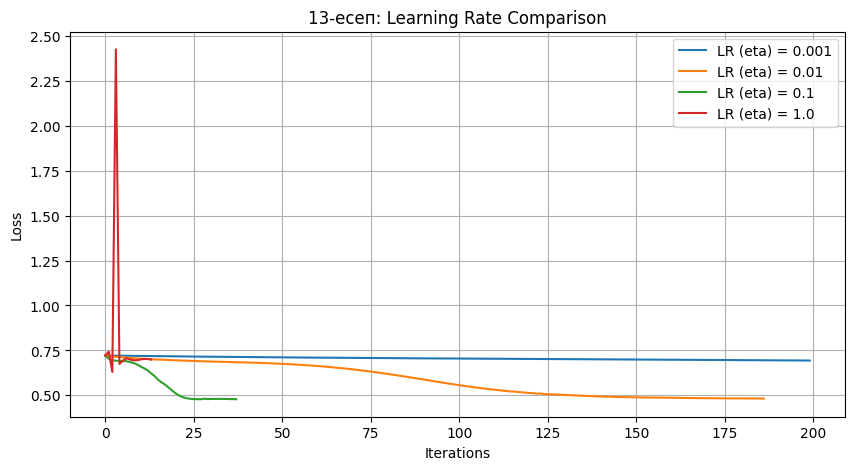

In [60]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
plt.figure(figsize=(10, 5))

for lr in learning_rates:
    mlp = MLPClassifier(hidden_layer_sizes=(4, 4), activation='relu',
                        learning_rate_init=lr, max_iter=200, random_state=1)
    mlp.fit(X, y)
    plt.plot(mlp.loss_curve_, label=f'LR (eta) = {lr}')

plt.title("13-есеп: Learning Rate Comparison")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Қорытынды:
### 1. η = 0.001: Оқыту өте баяу, модель оңтайлы нүктеге жету үшін көп уақытты қажет етеді

###2. η = 1.0: Жылдамдық тым жоғары болса, Loss секіруі немесе модельдің дивергенциясы (алшақтауы) мүмкін

### 3. Оптималды мән: Берілген тапсырма үшін көбінесе 0.1 немесе 0.01 ең тұрақты нәтиже көрсетеді

## IV. Ойлану және зерттеу есептері
## 14-есеп. Vanishing Gradient
### 1. **Себебі:** Тізбекті туындылау (chain rule) кезінде кіші туындыларды (мысалы, sigmoid туындысы max 0.25) бір-біріне көбейткенде, градиент нөлге жақындап кетеді
### 2. **Көмектеседі:** ReLU активациясы және Batch Normalization

## 15-есеп. Initialization

## 1. **Нөлмен инициализация:** Барлық нейрондар бірдей есептеулер жүргізеді (symmetry), желі күрделі заңдылықтарды үйрене алмайды

## 2. **Xavier vs He:** Xavier Sigmoid/Tanh үшін қолайлы.He (Kaiming) инициализациясы ReLU үшін дұрыс


## 16-есеп. Эссе
## **Тақырыбы:** «Forward және Backward propagation нейрондық желінің жүрегі ретінде»

### Кіріспе
### Нейрондық желілер — бұл деректерден заңдылықтарды үйренетін күрделі жүйелер. Бұл үйрену процесінің негізінде екі іргелі механизм жатыр: **Forward Propagation** (тура таралу) және **Backward Propagation** (кері таралу). Бұл екі процесс желінің "жүрек соғысы" іспеттес, онсыз машиналық оқыту мүмкін емес

### Forward Propagation: Болжам жасау
### Forward propagation кезеңінде ақпарат кіріс қабатынан шығысқа қарай жылжиды. Әрбір қабатта келесі формула бойынша есептеу жүреді:
### $$z = Wx + b$$
### Мұндағы $W$ — салмақтар, $b$ — биас. Содан кейін бейсызықтықты енгізу үшін активация функциясы қолданылады (мысалы, ReLU):
### $$a = f(z)$$
### Бұл кезеңнің мақсаты — нысанның класын немесе мәнін болжау ($\hat{y}$)

### Backward Propagation: Қатемен жұмыс
# Болжам жасалғаннан кейін, желі оның қаншалықты қате екенін **Loss Function** (жоғалту функциясы) арқылы анықтайды. Мысалы, Binary Cross-Entropy:
### $$L = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$
### Backward propagation кезінде градиенттер тізбекті туынды алу ережесі (chain rule) арқылы шығыстан кері қарай есептеледі. Бұл процесс әрбір салмақтың қателікке қаншалықты әсер еткенін көрсетеді ($\frac{\partial L}{\partial w}$).

### Салмақтарды жаңарту және практикалық маңызы
### Ең соңғы қадам — салмақтарды жаңарту:
### $$w_{new} = w - \eta \cdot \frac{\partial L}{\partial w}$$
### Мұндағы $\eta$ — оқыту жылдамдығы (learning rate). Практикада бұл цикл мыңдаған рет қайталанып, желінің дәлдігін арттырады. Осы механизмдердің арқасында нейрондық желілер кескіндерді тану, аударма жасау және басқа да күрделі тапсырмаларды орындай алады.

### Қорытынды
### Forward және Backward propagation — бұл нейрондық желінің интеллектуалды болуын қамтамасыз ететін қос қозғалтқыш. Тура таралу болжам жасаса, кері таралу сол болжамнан сабақ алып, жүйені жетілдіреді.